## SHAP IMPLEMENTATION

### Importing the data 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, recall_score, precision_score, f1_score
from math import sqrt
import os
import csv

# Load the dataset
file_path = '/work/Downloaded/vbd-richard-bernat/trainn.csv'
data = pd.read_csv(file_path)

# Placeholder for dataset preprocessing
#target = 'your_target_column'
#features = data.drop(target, axis=1)

from sklearn.preprocessing import LabelEncoder

# Encoding the target variable
label_encoder = LabelEncoder()
data['prognosis_encoded'] = label_encoder.fit_transform(data['prognosis'])

# Separating features and target variable
#X = data.drop(['id', 'prognosis', 'prognosis_encoded'], axis=1)
X = data.drop(['prognosis', 'prognosis_encoded'], axis=1)
y = data['prognosis_encoded']



# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=29)

# Mapping original class labels to their encoded values
encoded_labels = {label: index for index, label in enumerate(label_encoder.classes_)}

print("Encoded Labels:")
for label, encoded in encoded_labels.items():
    print(f"{label}: {encoded}")


Encoded Labels:
Chikungunya: 0
Dengue: 1
Japanese encephalitis: 2
Lyme disease: 3
Malaria: 4
Plague: 5
Rift Valley fever: 6
Tungiasis: 7
West Nile fever: 8
Yellow Fever: 9
Zika: 10


### Importing the models 

In [ ]:
import joblib  
from tensorflow.keras.models import load_model
rf = joblib.load('/work/models/best_rf_model.joblib')
xg_boost = joblib.load('/work/models/best_xgb_model.joblib')

In [ ]:
!pip install shap
import shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.9/539.9 kB 28.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 48.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 MB 24.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 24.1.2
[notice] To update, run: pip install --upgrade pip
/shared-libs/python3.9/py/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### SHAP Analysis - Random Forest classifier

In [ ]:
# Y_PRED CONTAINS THE PREDICTED CLASS LABELS FOR EACH INSTANCE IN THE VALIDATION DATASET, OBTAINED USING THE RANDOM FOREST CLASSIFIER (RF_CLASSIFIER).
y_pred = rf.predict(X_test)
print("model's predicted class labels:")
print(list(y_pred))

model's predicted class labels:
[3, 8, 7, 7, 6, 4, 7, 6, 8, 8, 2, 0, 9, 4, 0, 8, 9, 9, 4, 8, 4, 3, 7, 6, 0, 3, 4, 9, 10, 4, 8, 10, 5, 0, 5, 9, 2, 3, 3, 6, 3, 8, 0, 1, 10, 6, 0, 2, 1, 2, 7, 2, 4, 5, 7, 9, 9, 2, 4, 10, 7, 3, 5, 6, 10, 4, 1, 2, 0, 8, 6, 2, 10, 5, 9, 4]


In [ ]:
# Actual class labels
print("original class labels:")
print(list(y_test))

original class labels:
[3, 8, 7, 7, 6, 4, 7, 6, 8, 8, 2, 0, 10, 4, 0, 8, 9, 9, 6, 8, 4, 3, 7, 6, 0, 3, 4, 10, 10, 4, 8, 10, 5, 1, 5, 9, 2, 3, 3, 1, 3, 8, 0, 1, 10, 6, 1, 2, 1, 2, 7, 2, 4, 5, 7, 9, 9, 2, 4, 10, 7, 3, 5, 1, 10, 4, 1, 2, 0, 8, 6, 2, 10, 5, 9, 4]


In [ ]:
# Initialize the TreeExplainer
explainer = shap.TreeExplainer(rf)

# Compute SHAP values
shap_values = explainer.shap_values(X_test, y=None, tree_limit=None, approximate=False, check_additivity=True)

# Print size of SHAP values for test set
#print("Shape of SHAP values for test set:", shap_values.shape)

SUMMARY PLOT FOR ALL CLASSES

SUMMARY PLOT  FOR CLASS LABEL = Chikungunya(0)


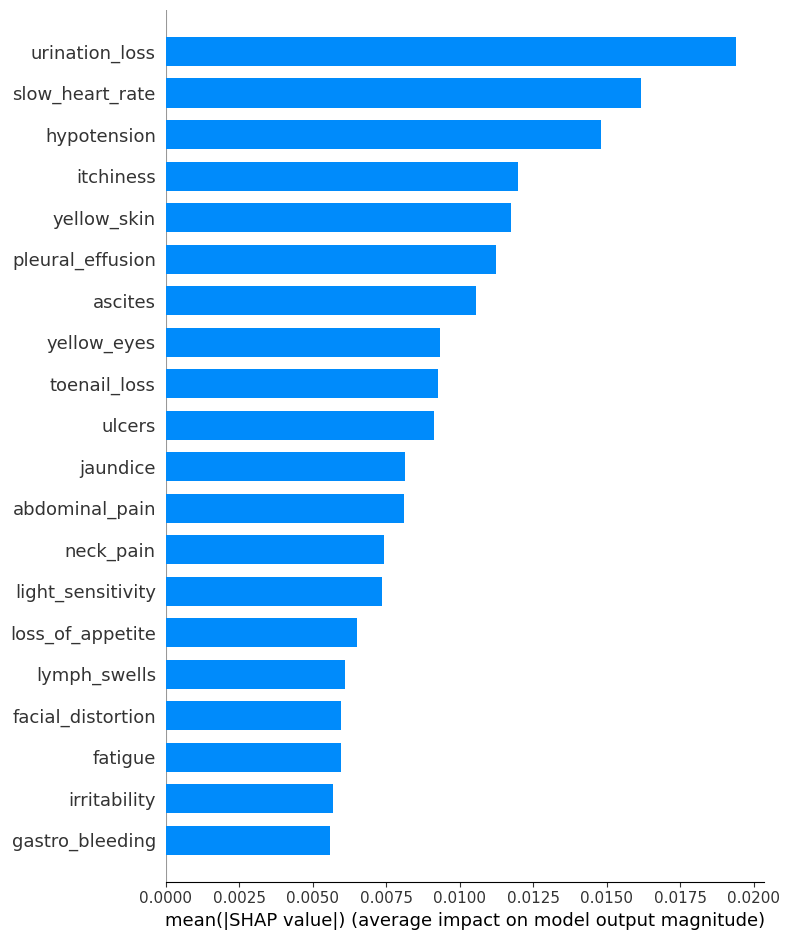

In [ ]:
#SUMMARY PLOT  FOR CLASS LABEL = Chikungunya : 0

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 0]
print("SUMMARY PLOT  FOR CLASS LABEL = Chikungunya(0)")

# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[0], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class=0
shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")

SUMMARY PLOT FOR CLASS LABEL = Dengue: 1


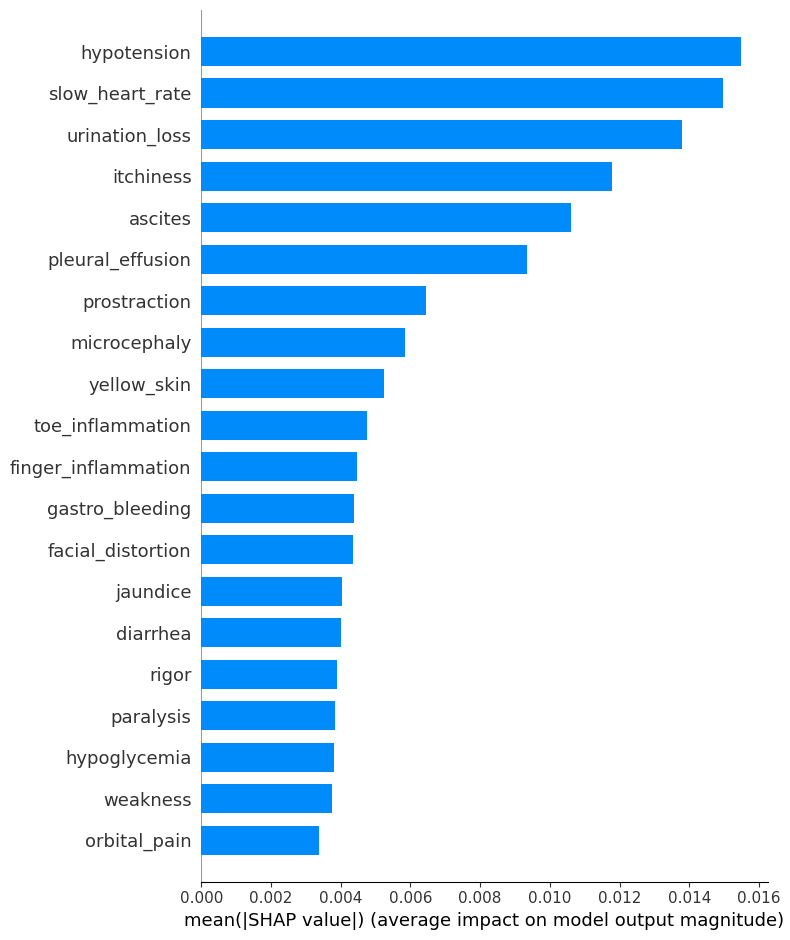

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = Dengue: 1

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 1]
print("SUMMARY PLOT FOR CLASS LABEL = Dengue: 1")
# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[1], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class
shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")

SUMMARY PLOT FOR CLASS LABEL = Japanese encephalitis: 2


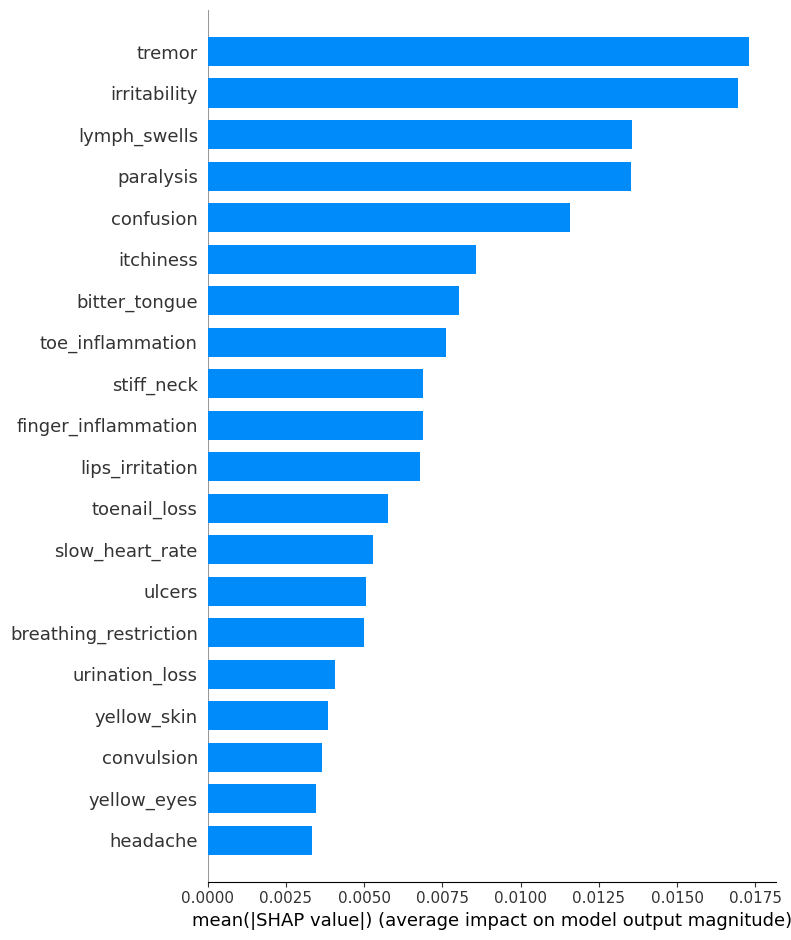

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = Japanese encephalitis: 2

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 2]
print("SUMMARY PLOT FOR CLASS LABEL = Japanese encephalitis: 2")
# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[2], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class)
shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")

SUMMARY PLOT FOR CLASS LABEL = Lyme disease: 3


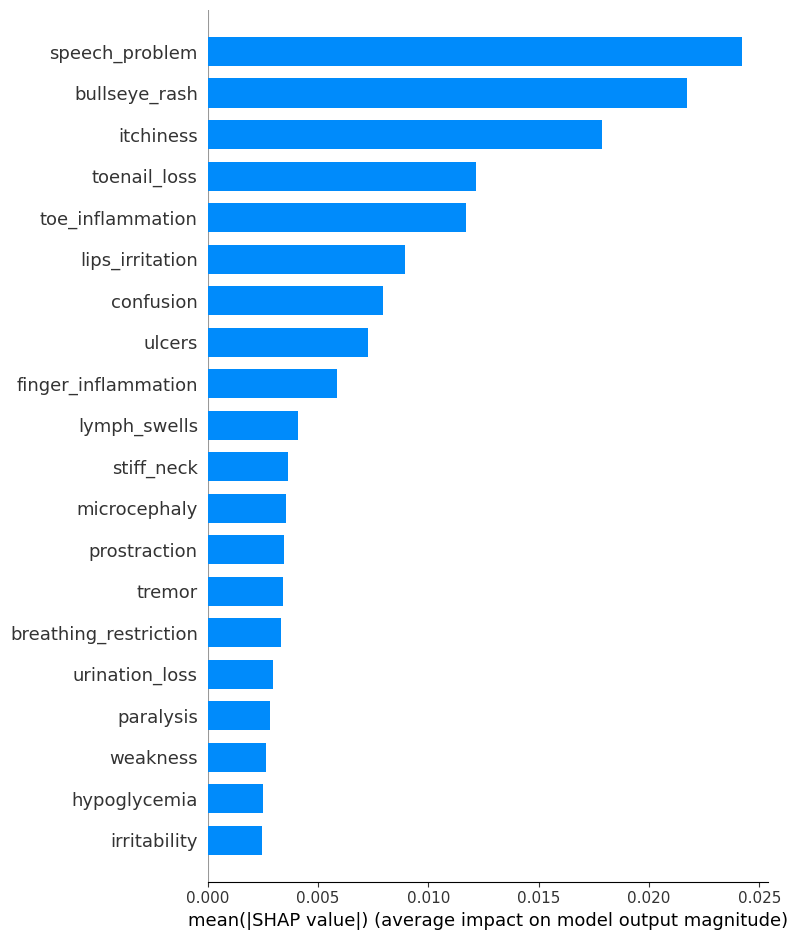

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = Lyme disease: 3

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 3]
print("SUMMARY PLOT FOR CLASS LABEL = Lyme disease: 3")

# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[3], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class

shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")


SUMMARY PLOT FOR CLASS LABEL = Malaria: 4




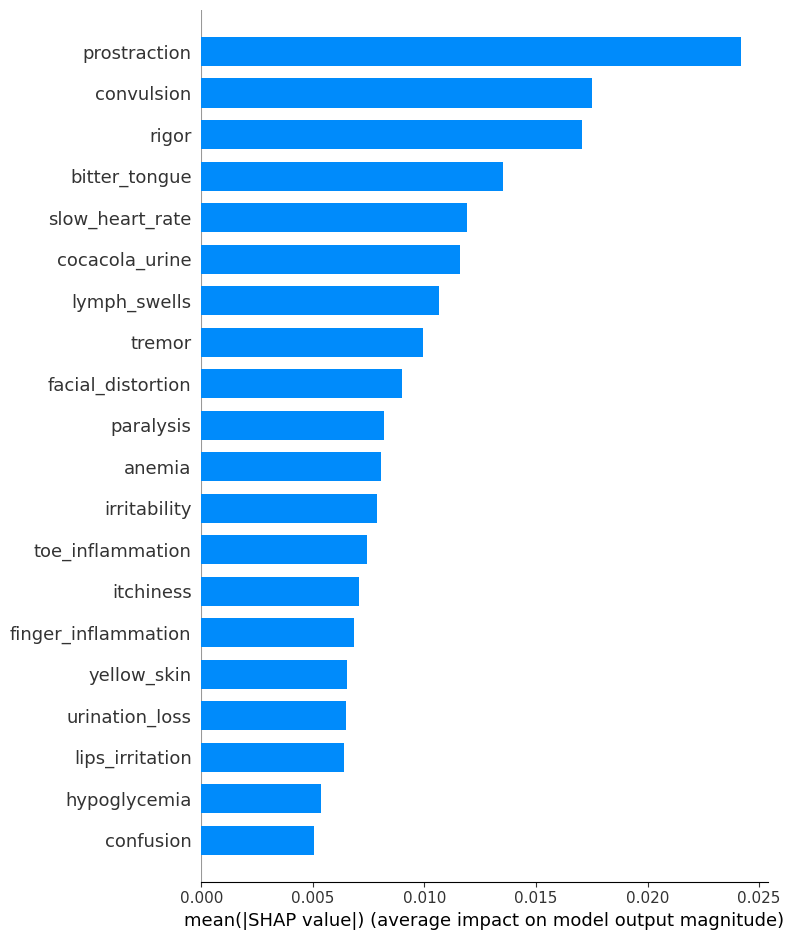

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = Malaria: 4

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 4]
print("SUMMARY PLOT FOR CLASS LABEL = Malaria: 4")
print("\n")
# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[4], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class

shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")


SUMMARY PLOT FOR CLASS LABEL = Plague: 5




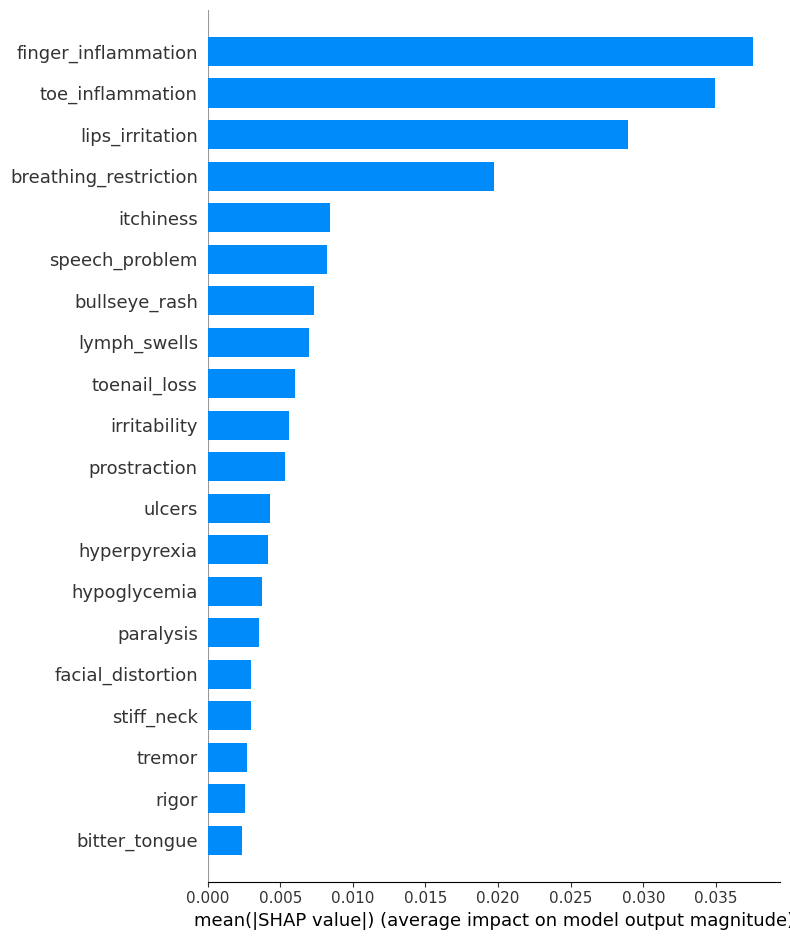

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = Plague: 5

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 5]
print("SUMMARY PLOT FOR CLASS LABEL = Plague: 5")
print("\n")
# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[5], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class

shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")


SUMMARY PLOT FOR CLASS LABEL = Rift Valley fever: 6


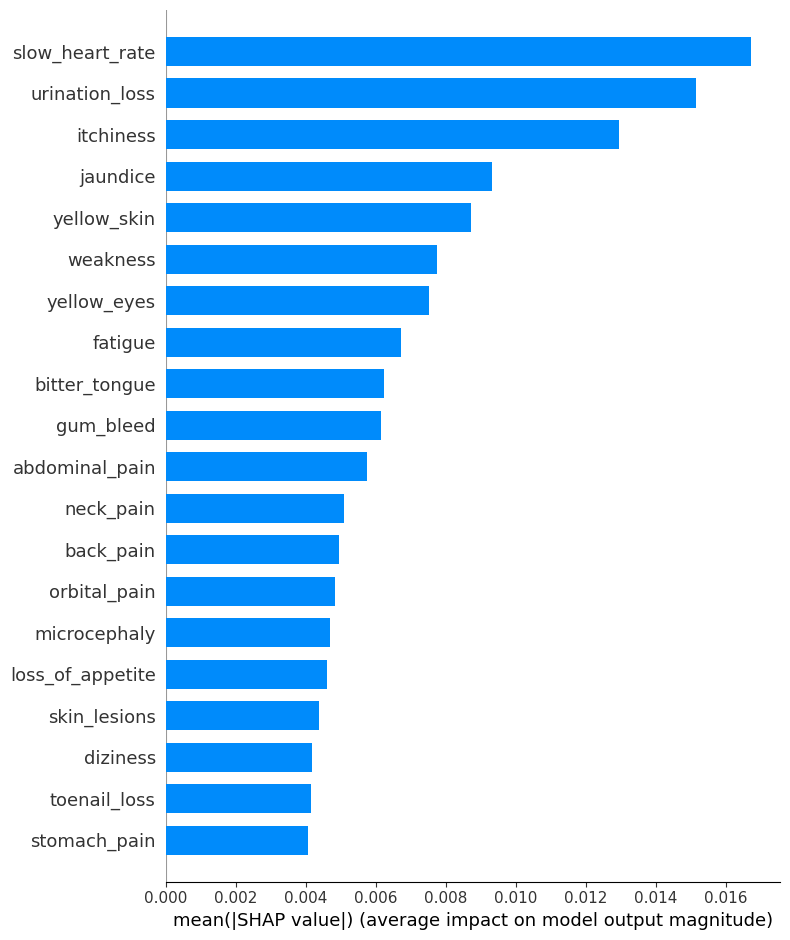

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = Rift Valley fever: 6

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 6]
print("SUMMARY PLOT FOR CLASS LABEL = Rift Valley fever: 6")

# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[6], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class


shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")


SUMMARY PLOT FOR CLASS LABEL = Tungiasis: 7


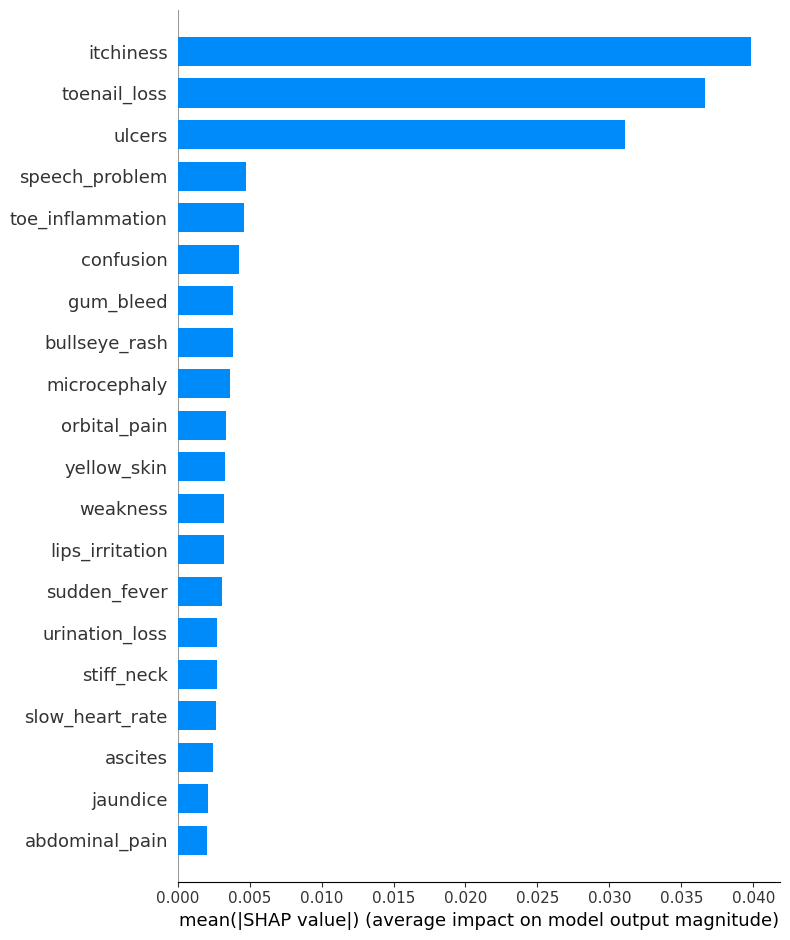

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = Tungiasis: 7

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 7]
print("SUMMARY PLOT FOR CLASS LABEL = Tungiasis: 7")

# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[7], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class

shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")


SUMMARY PLOT FOR CLASS LABEL = West Nile fever: 8


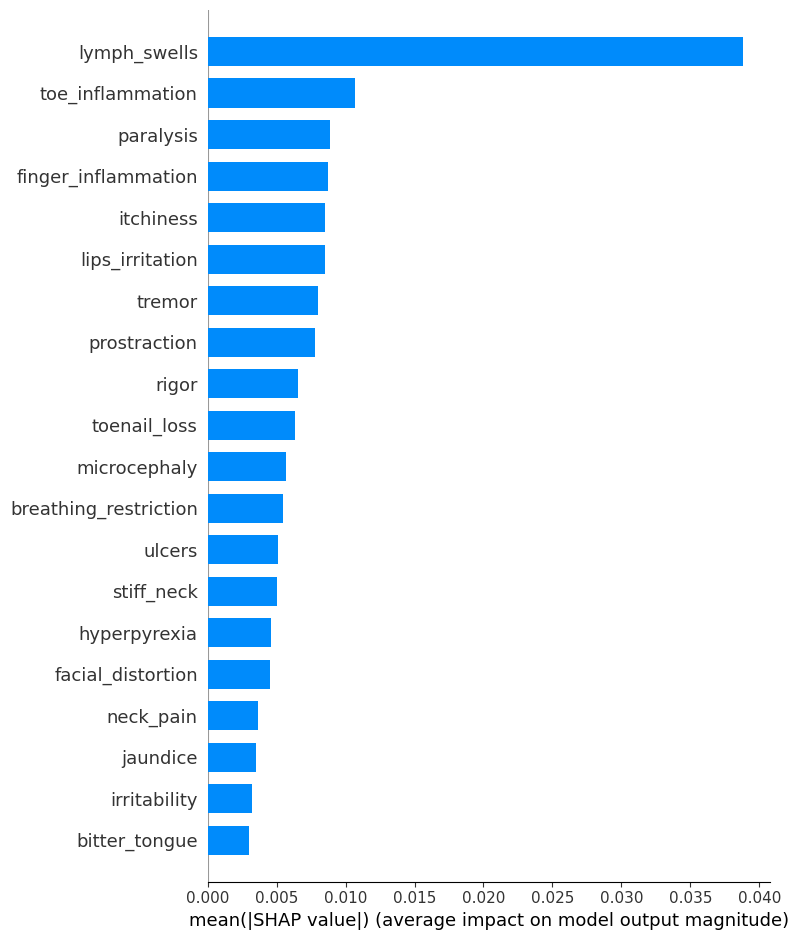

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = West Nile fever: 8
# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 8]
print("SUMMARY PLOT FOR CLASS LABEL = West Nile fever: 8")

# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[8], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class

shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")


SUMMARY PLOT FOR CLASS LABEL = Yellow Fever: 9


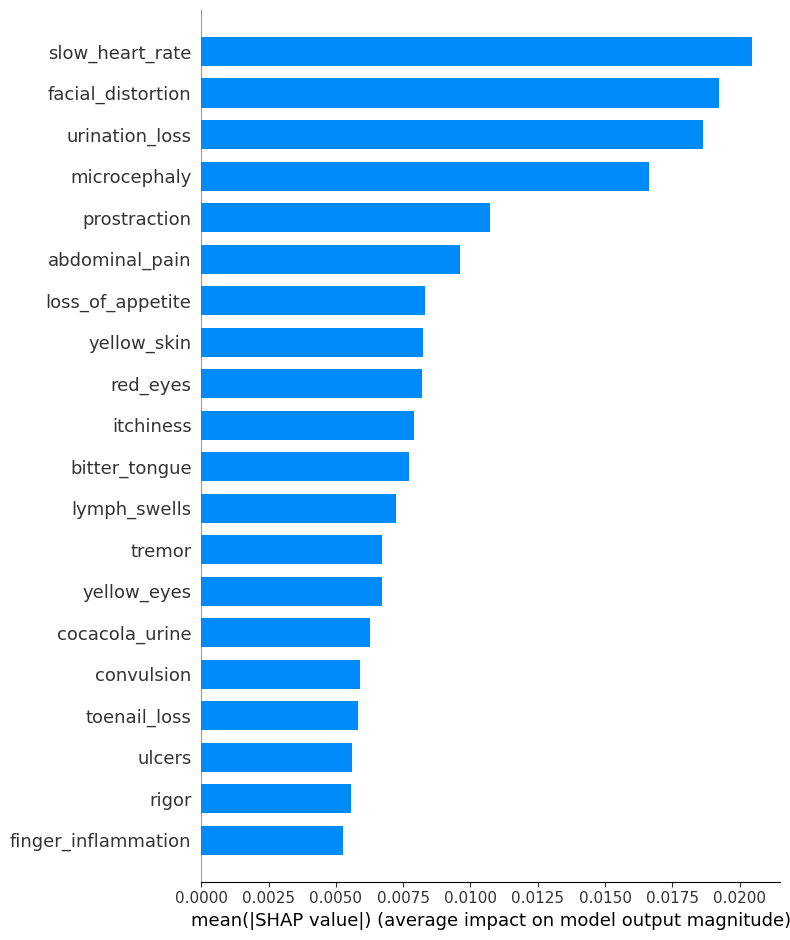

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = Yellow Fever: 9

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 9]
print("SUMMARY PLOT FOR CLASS LABEL = Yellow Fever: 9")

# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[9], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class

shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")


SUMMARY PLOT FOR CLASS LABEL = Zika: 10


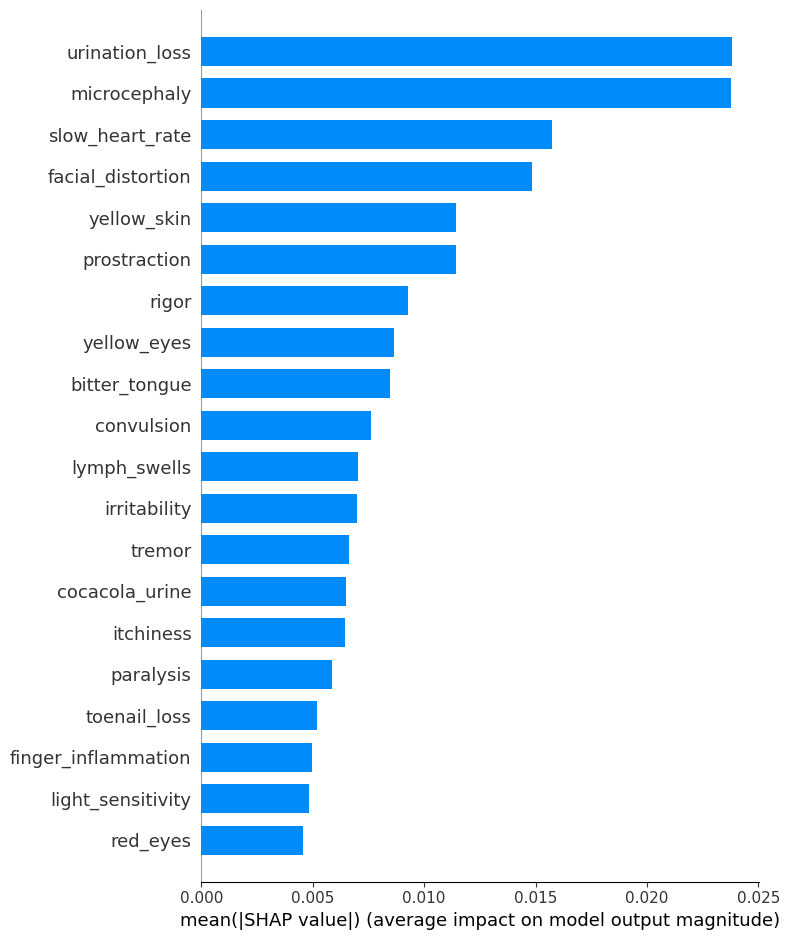

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = Zika: 10

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 10]
print("SUMMARY PLOT FOR CLASS LABEL = Zika: 10")

# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[10], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class

shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")


BAR PLOT


Original Class: Zika
Predicted Class by Model: Yellow Fever

Bar plot: Zika


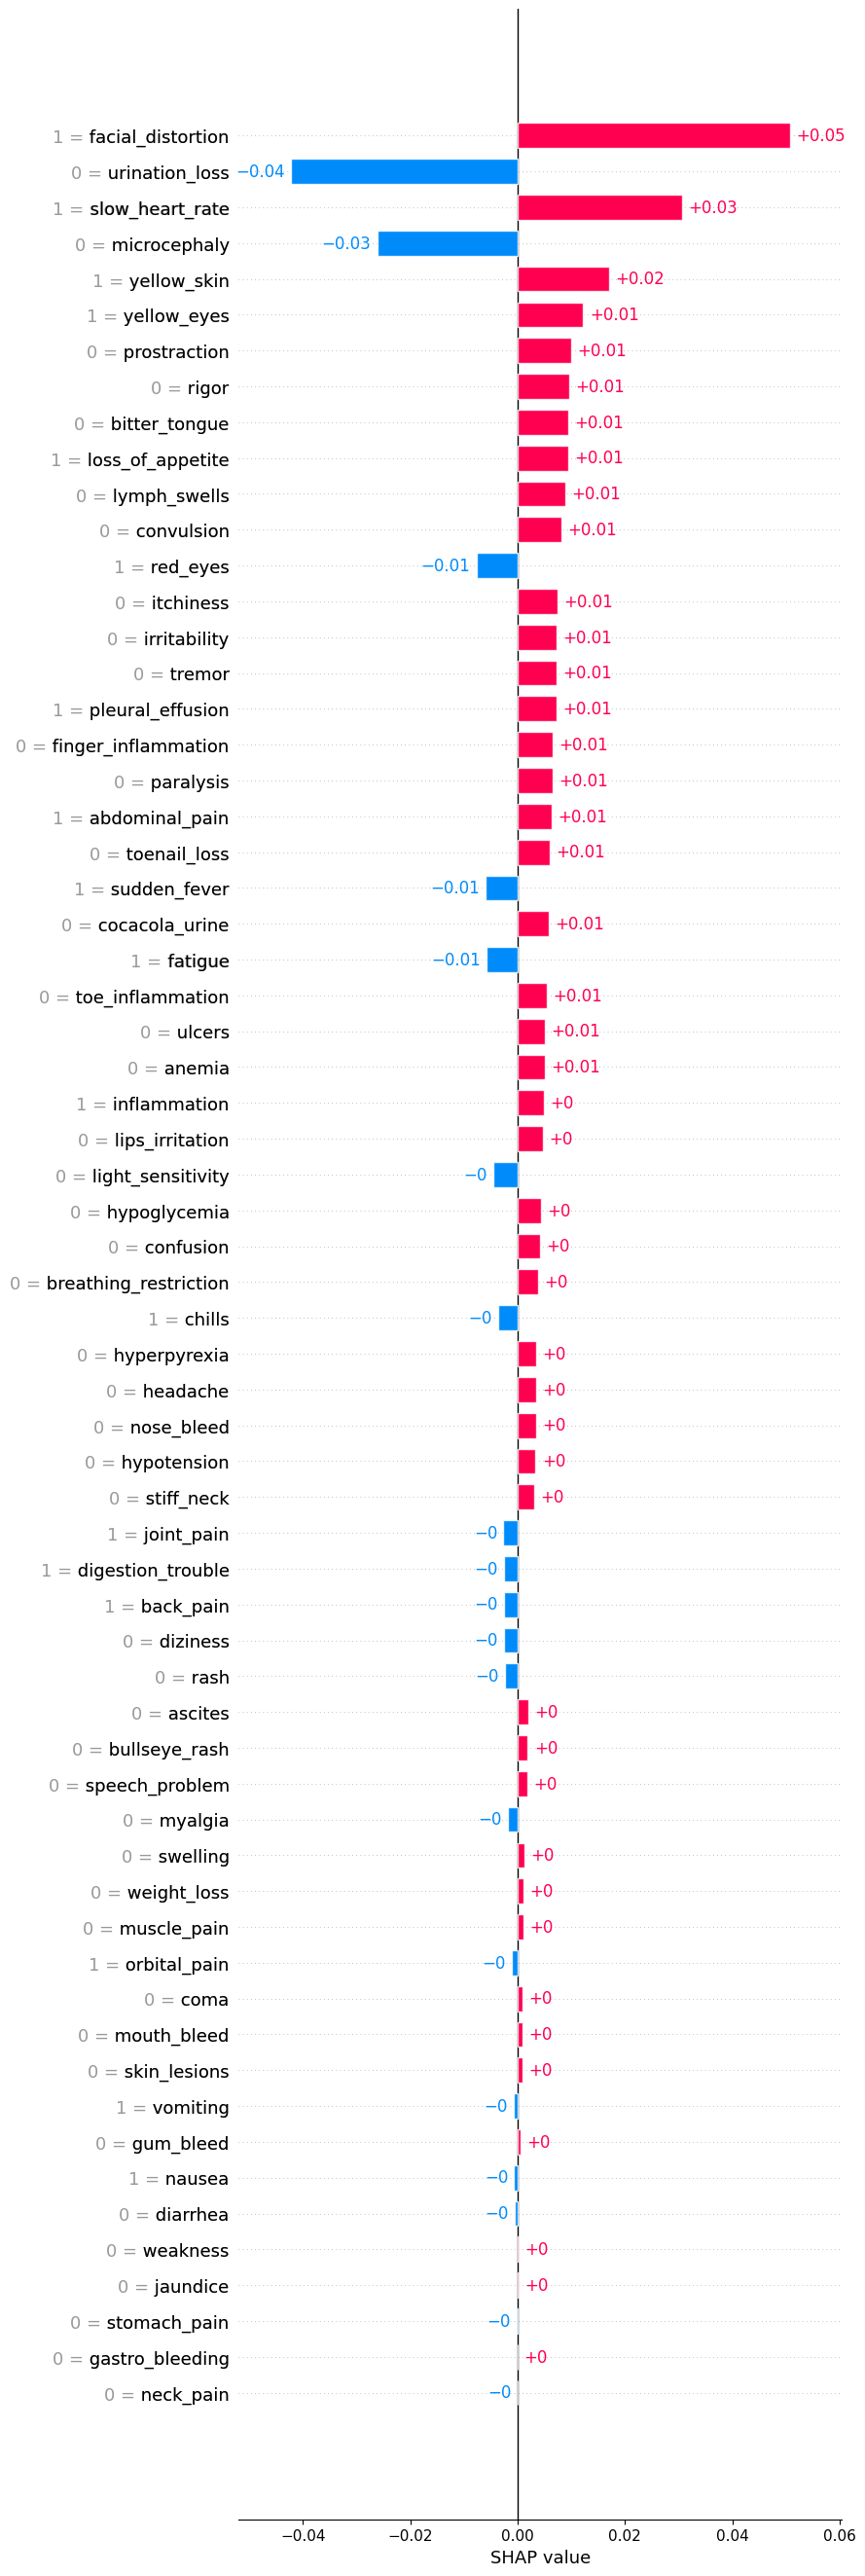


Bar plot:: Yellow Fever


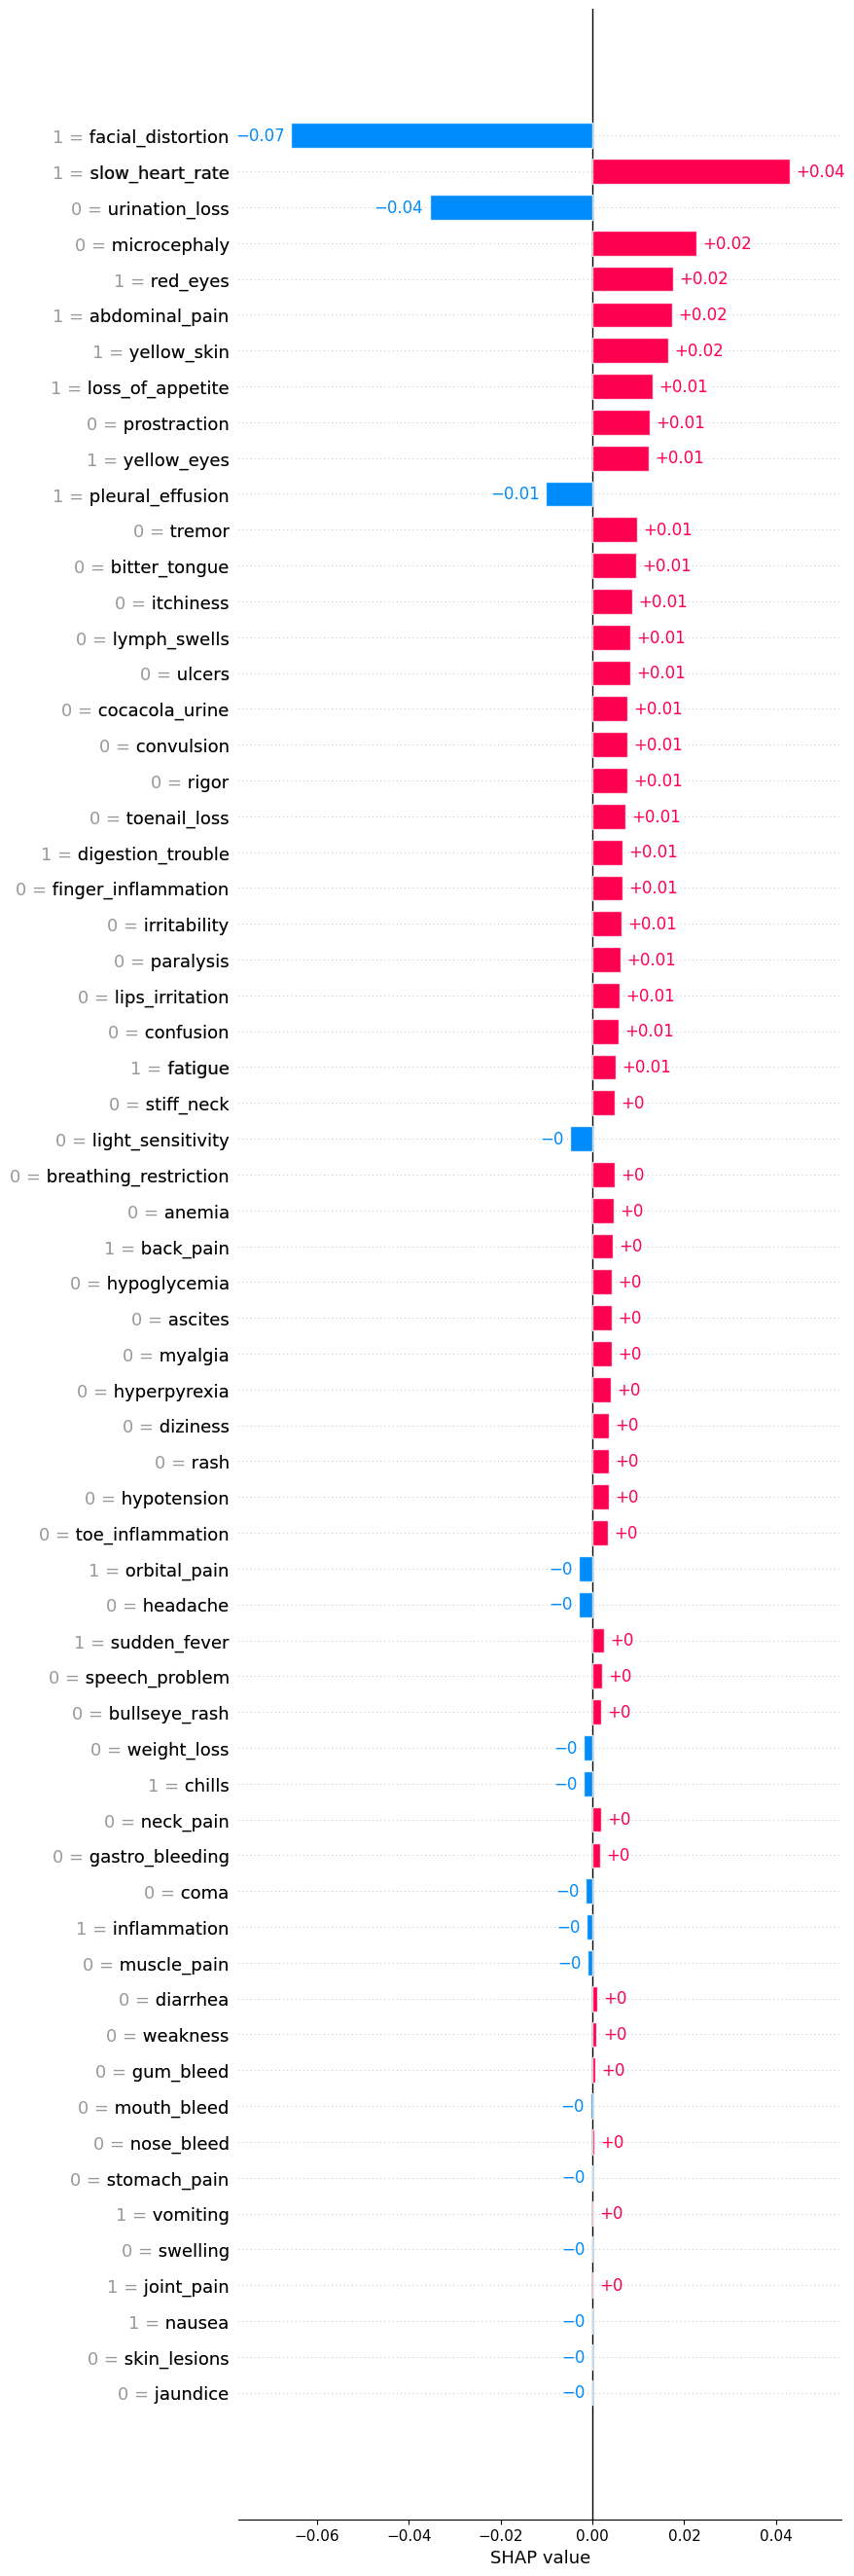

In [ ]:
# Print original and predicted class labels by the model for sample at index 12
y_pred = rf.predict(X_test)
original_class = label_encoder.inverse_transform([y_test.iloc[12]])[0]
predicted_class = label_encoder.inverse_transform([y_pred[12]])[0]

print(f"\nOriginal Class: {original_class}")
print(f"Predicted Class by Model: {predicted_class}")

#print(f"\nOriginal Class: {original_class}")
print(f"\nBar plot: {original_class}")
import shap
import xgboost as xgb
import pandas as pd

# Assuming shap_values is already computed for a multi-class classification model
shap_values = explainer.shap_values(X_test)

# Select SHAP values for sample at index 12, all features, and only for the class=10 (index 10)
shap_values_sample12_class10 = shap_values[12, :, 10]

# Ensure X_test is a DataFrame to have column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Create an Explanation object for the specific sample (index 12) and class=10
explanation = shap.Explanation(values=shap_values_sample12_class10,
                               base_values=explainer.expected_value[10],
                               data=X_test.iloc[12],  # Select the specific sample (index 12)
                               feature_names=feature_names)

# Generate bar plot for the selected sample and class=10
shap.plots.bar(explanation,max_display=65, show=True)




#print(f"Predicted Class by Model: {predicted_class}")
print(f"\nBar plot:: {predicted_class}")

# Select SHAP values for sample at index 12, all features, and only for the class=9 (index 9)
shap_values_sample12_class9 = shap_values[12, :, 9]

# Create an Explanation object for the specific sample (index 12) and class=9
explanation_yellow_fever = shap.Explanation(values=shap_values_sample12_class9,
                                            base_values=explainer.expected_value[9],
                                            data=X_test.iloc[12],  # Select the specific sample (index 12)
                                            feature_names=feature_names)

# Generate bar plot for the selected sample and class=9 (Yellow Fever)
shap.plots.bar(explanation_yellow_fever,max_display=65, show=True)




## SHAP Analysis - Gradient Boosting Classifier

In [ ]:
# Y_PRED CONTAINS THE PREDICTED CLASS LABELS FOR EACH INSTANCE IN THE VALIDATION DATASET, OBTAINED USING xgb.
y_pred = xg_boost.predict(X_test)
print("model's predicted class labels:")
print(list(y_pred))

model's predicted class labels:
[3, 8, 7, 7, 6, 4, 7, 6, 8, 8, 2, 0, 9, 4, 0, 8, 9, 9, 6, 8, 4, 3, 7, 6, 0, 3, 4, 1, 10, 4, 8, 10, 5, 0, 5, 9, 2, 3, 3, 1, 3, 8, 0, 1, 10, 6, 3, 6, 1, 2, 7, 2, 4, 5, 7, 9, 9, 2, 4, 10, 7, 3, 5, 6, 10, 4, 1, 2, 0, 8, 6, 2, 10, 5, 9, 4]


In [ ]:
# Actual class labels
print("original class labels:")
print(list(y_test))

original class labels:
[3, 8, 7, 7, 6, 4, 7, 6, 8, 8, 2, 0, 10, 4, 0, 8, 9, 9, 6, 8, 4, 3, 7, 6, 0, 3, 4, 10, 10, 4, 8, 10, 5, 1, 5, 9, 2, 3, 3, 1, 3, 8, 0, 1, 10, 6, 1, 2, 1, 2, 7, 2, 4, 5, 7, 9, 9, 2, 4, 10, 7, 3, 5, 1, 10, 4, 1, 2, 0, 8, 6, 2, 10, 5, 9, 4]


In [ ]:
# Print the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the xg_boost model: {accuracy:.4f}")

Accuracy of the xg_boost model: 0.9211


In [ ]:
# Initialize the TreeExplainer
explainer = shap.TreeExplainer(xg_boost)

# Compute SHAP values
shap_values = explainer.shap_values(X_test, y=None, tree_limit=None, approximate=False, check_additivity=True)


SUMMARY PLOT FOR ALL CLASSES

SUMMARY PLOT  FOR CLASS LABEL = Chikungunya(0)


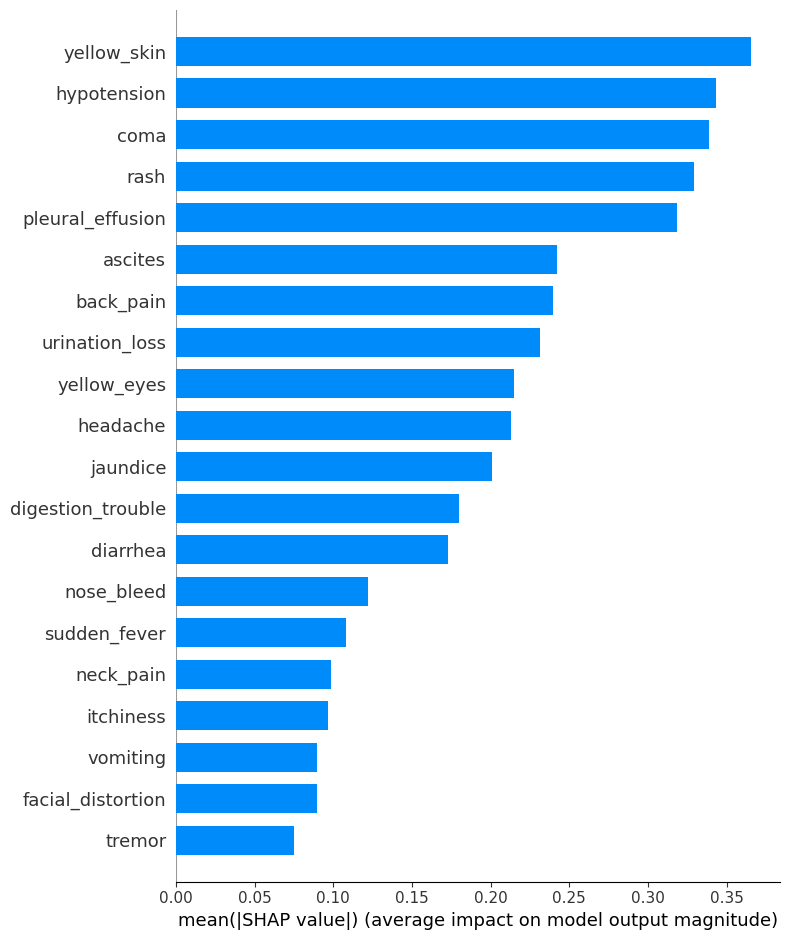

In [ ]:
#SUMMARY PLOT  FOR CLASS LABEL = Chikungunya : 0

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 0]
print("SUMMARY PLOT  FOR CLASS LABEL = Chikungunya(0)")

# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[0], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class=0
shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")

SUMMARY PLOT  FOR CLASS LABEL = Dengue(1)


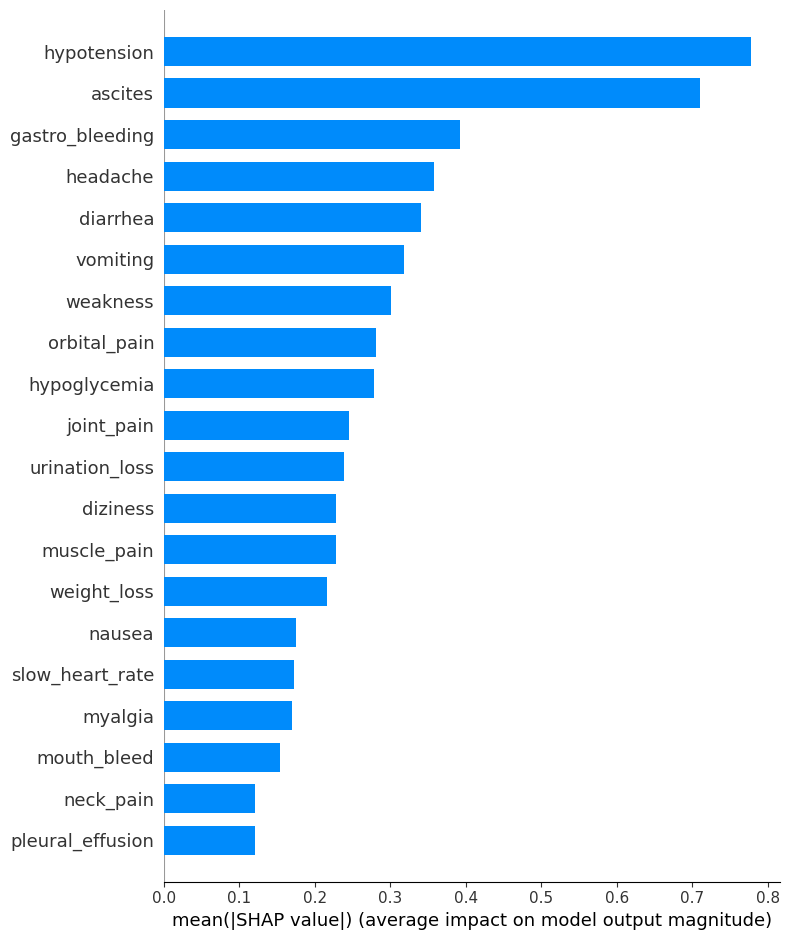

In [ ]:
#SUMMARY PLOT  FOR CLASS LABEL = Dengue : 1

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 1]
print("SUMMARY PLOT  FOR CLASS LABEL = Dengue(1)")

# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[1], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class
shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")

SUMMARY PLOT FOR CLASS LABEL = Japanese encephalitis: 2


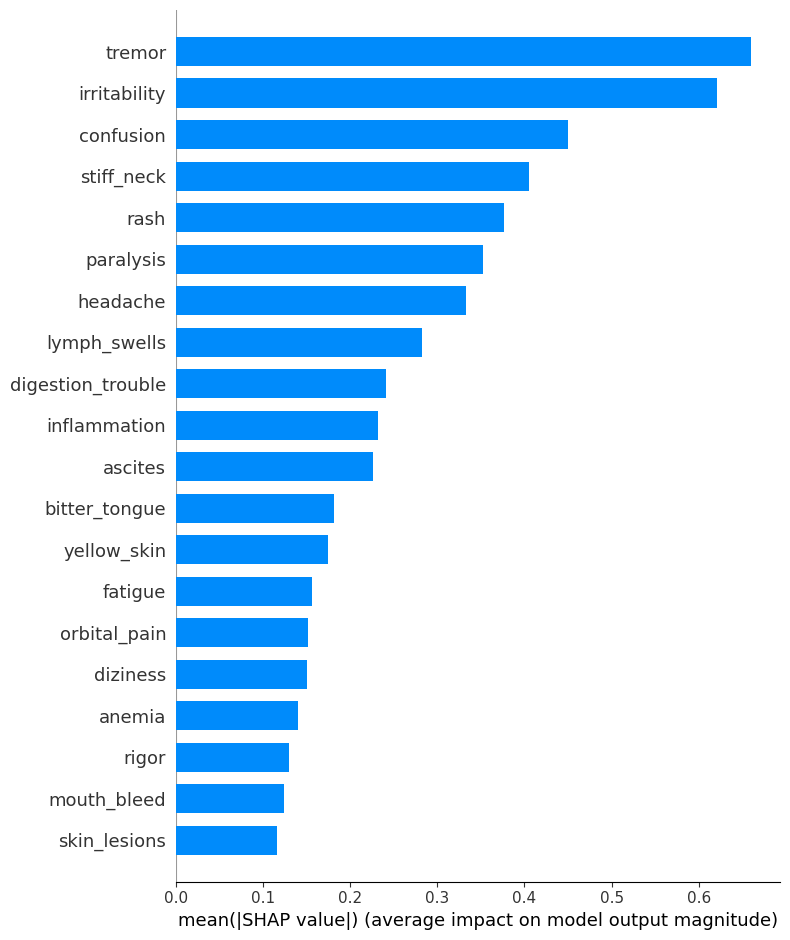

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = Japanese encephalitis: 2

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 2]
print("SUMMARY PLOT FOR CLASS LABEL = Japanese encephalitis: 2")
# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[2], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class)
shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")

SUMMARY PLOT FOR CLASS LABEL = Lyme disease: 3


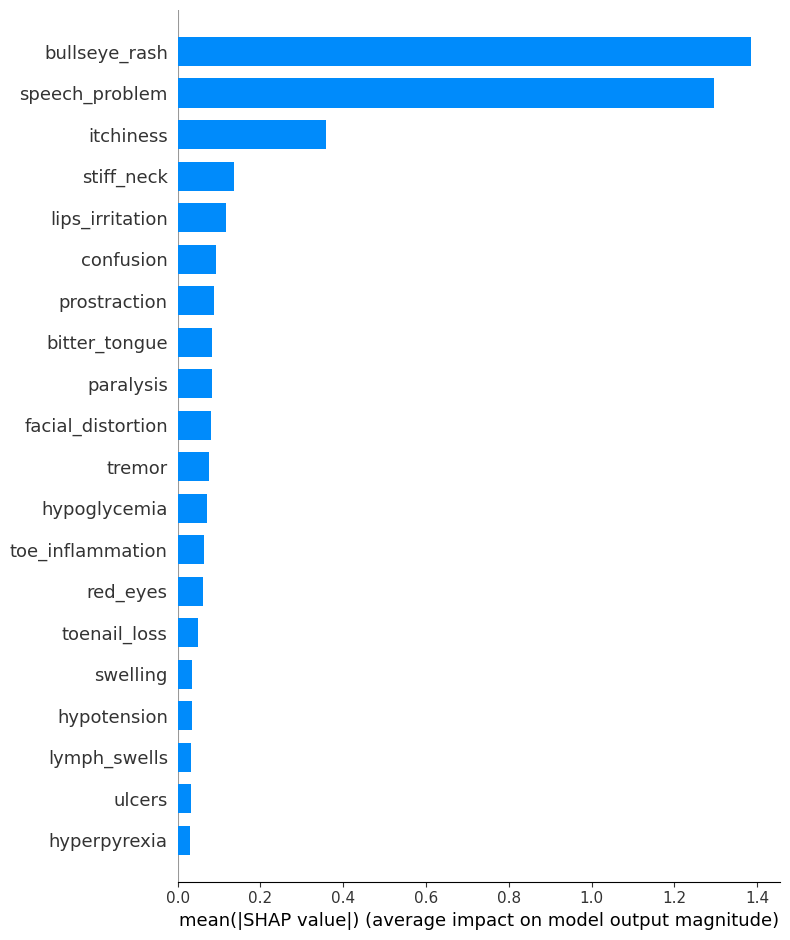

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = Lyme disease: 3

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 3]
print("SUMMARY PLOT FOR CLASS LABEL = Lyme disease: 3")

# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[3], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class

shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")


SUMMARY PLOT FOR CLASS LABEL = Malaria: 4




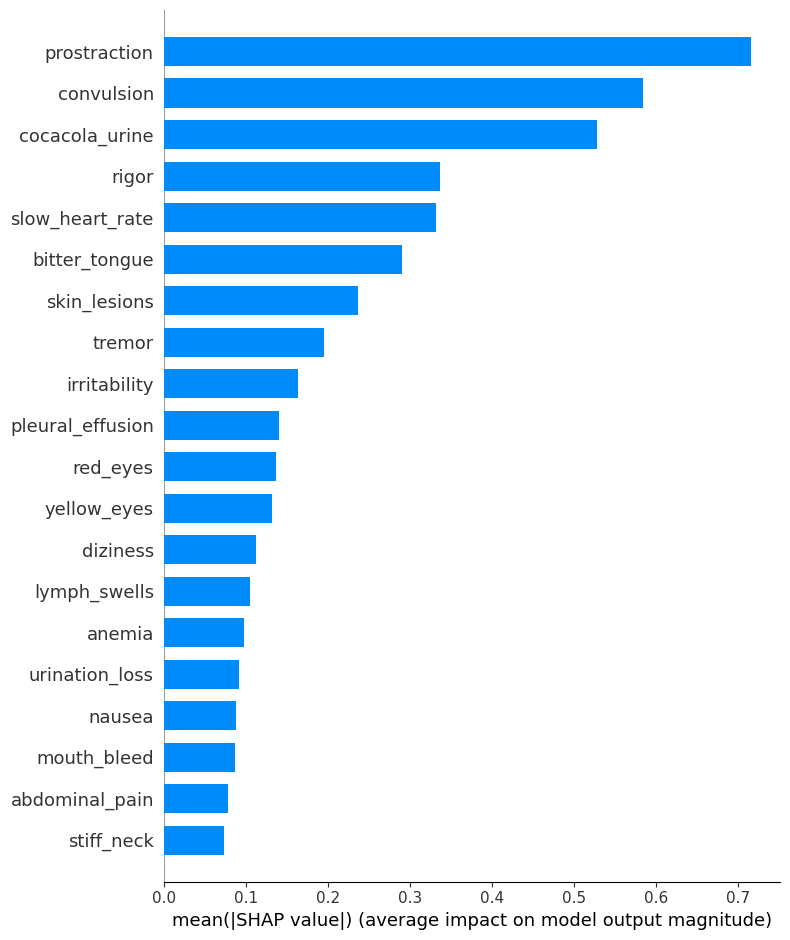

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = Malaria: 4

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 4]
print("SUMMARY PLOT FOR CLASS LABEL = Malaria: 4")
print("\n")
# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[4], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class

shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")


SUMMARY PLOT FOR CLASS LABEL = Plague: 5




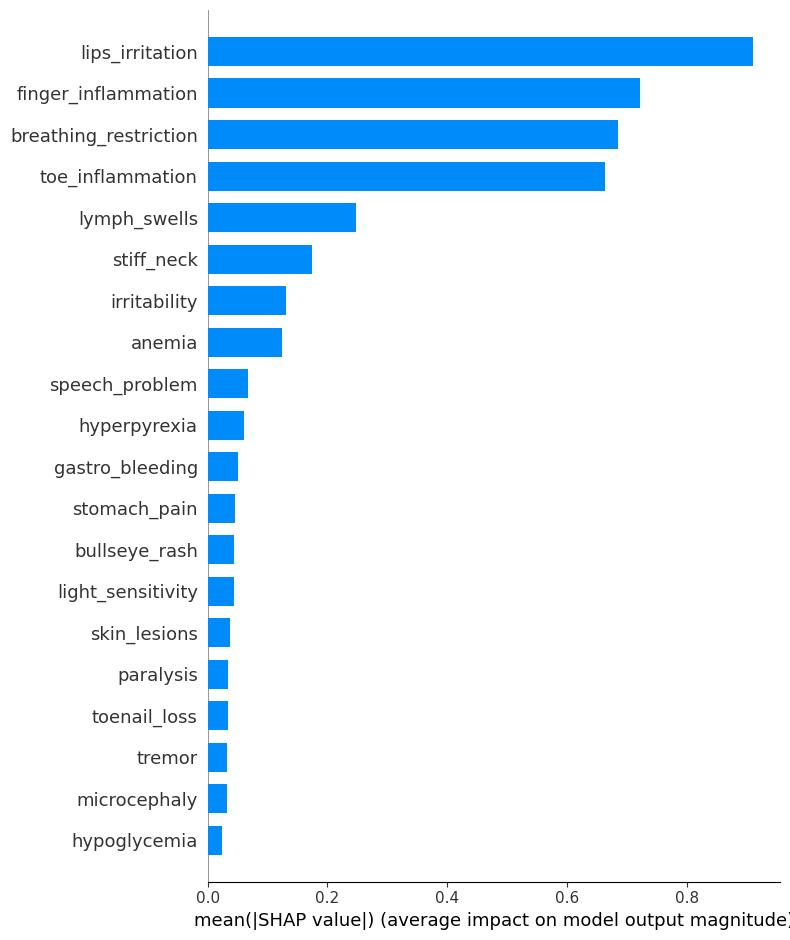

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = Plague: 5

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 5]
print("SUMMARY PLOT FOR CLASS LABEL = Plague: 5")
print("\n")
# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[5], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class

shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")


SUMMARY PLOT FOR CLASS LABEL = Rift Valley fever: 6


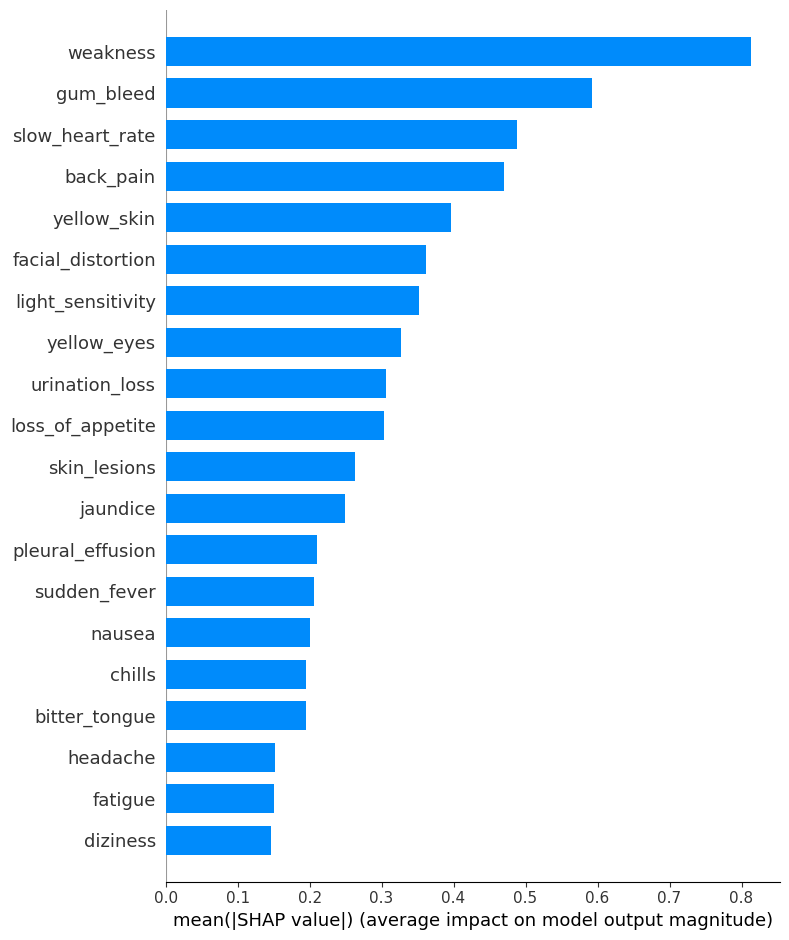

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = Rift Valley fever: 6

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 6]
print("SUMMARY PLOT FOR CLASS LABEL = Rift Valley fever: 6")

# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[6], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class


shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")


SUMMARY PLOT FOR CLASS LABEL = Tungiasis: 7


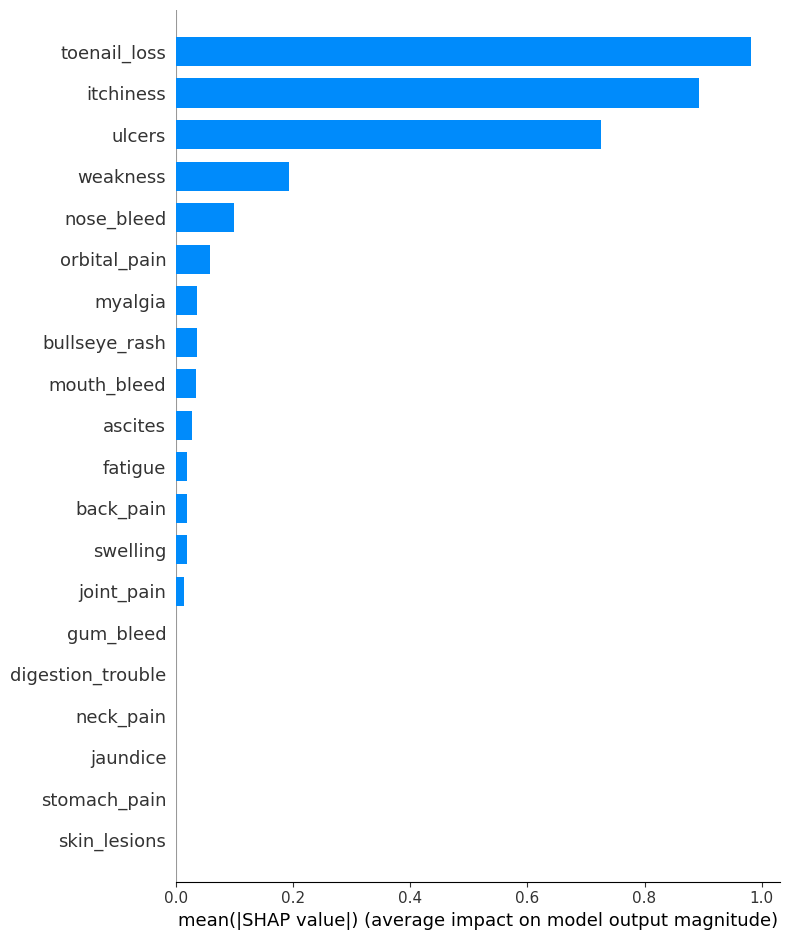

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = Tungiasis: 7

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 7]
print("SUMMARY PLOT FOR CLASS LABEL = Tungiasis: 7")

# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[7], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class

shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")


SUMMARY PLOT FOR CLASS LABEL = West Nile fever: 8


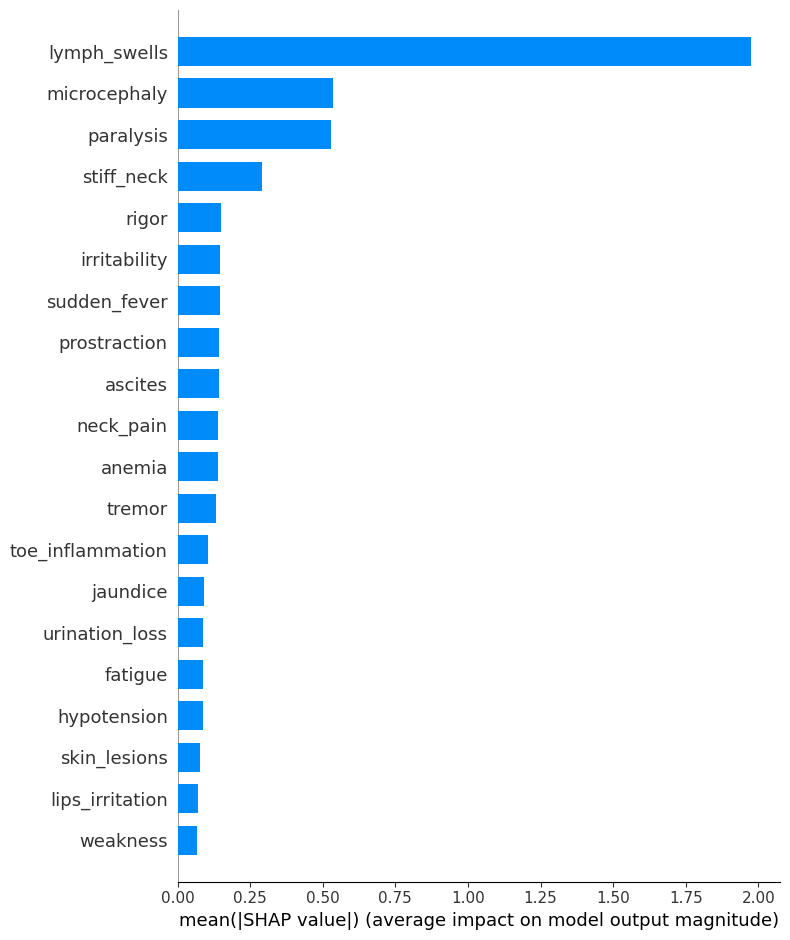

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = West Nile fever: 8
# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 8]
print("SUMMARY PLOT FOR CLASS LABEL = West Nile fever: 8")

# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[8], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class

shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")


SUMMARY PLOT FOR CLASS LABEL = Yellow Fever: 9


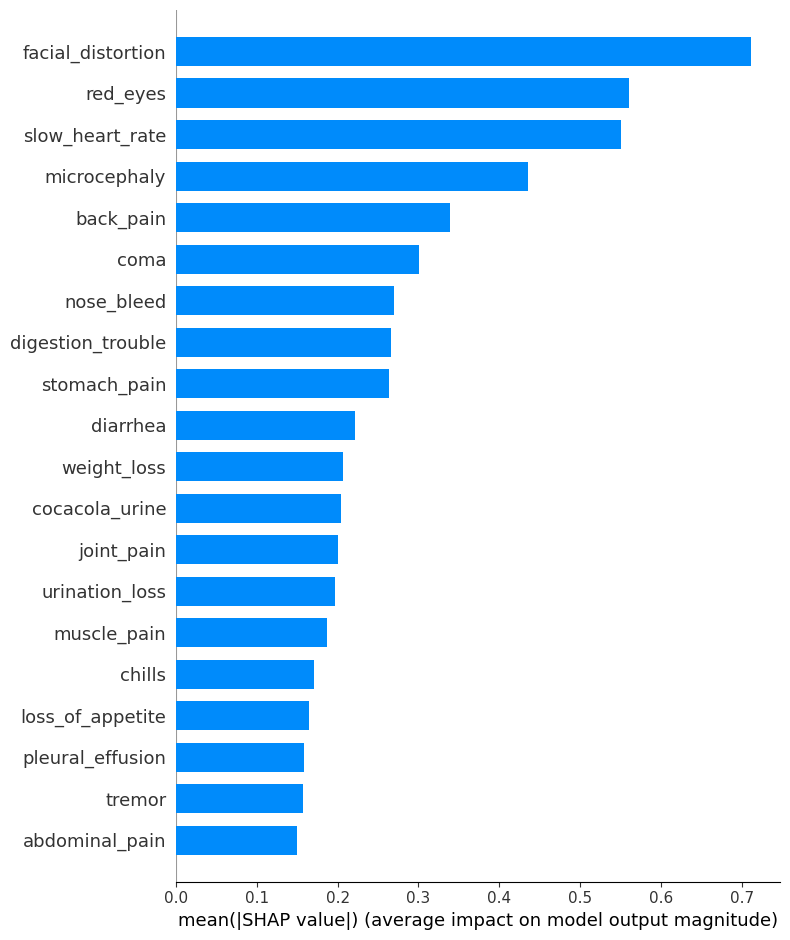

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = Yellow Fever: 9

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 9]
print("SUMMARY PLOT FOR CLASS LABEL = Yellow Fever: 9")

# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[9], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class

shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")


SUMMARY PLOT FOR CLASS LABEL = Zika: 10


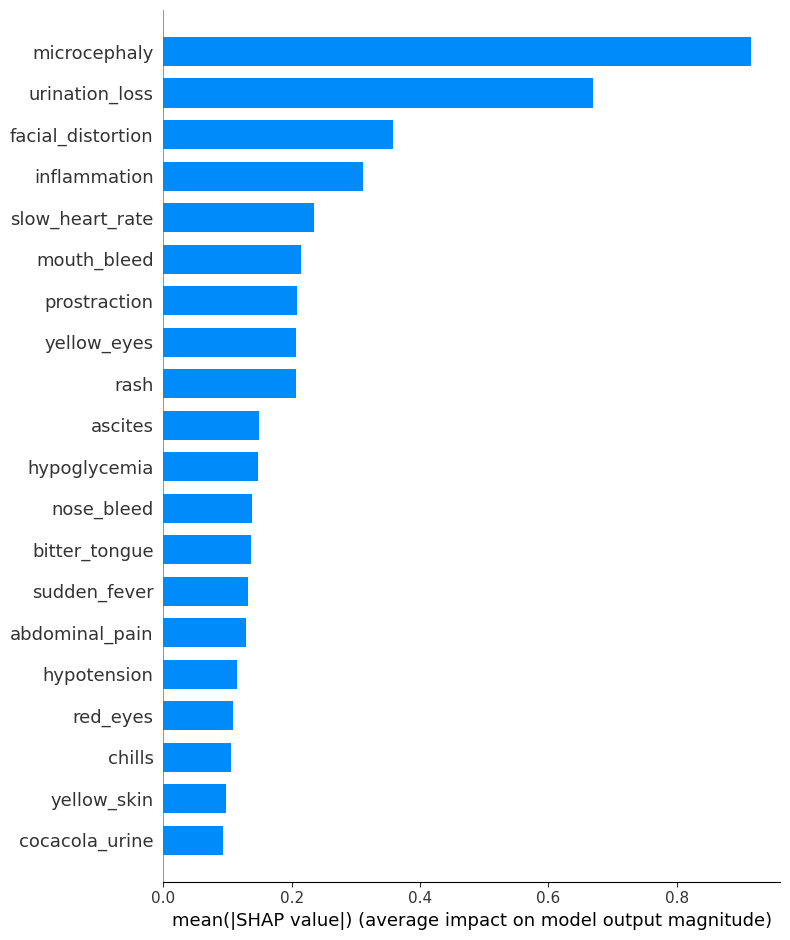

In [ ]:
#SUMMARY PLOT FOR CLASS LABEL = Zika: 10

# column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Select SHAP values for a specific class
shap_values_class = shap_values[..., 10]
print("SUMMARY PLOT FOR CLASS LABEL = Zika: 10")

# Create an Explanation object
explanation = shap.Explanation(values=shap_values_class, base_values=explainer.expected_value[10], data=X_test, feature_names=feature_names)
#shap.summary_plot generates a summary plot of SHAP values (shap_values_class) for the selected class

shap.summary_plot(shap_values_class, X_test, feature_names=feature_names,  plot_type="bar")


BAR PLOT


Original Class: Zika
Predicted Class by Model: Yellow Fever

Bar plot: Zika


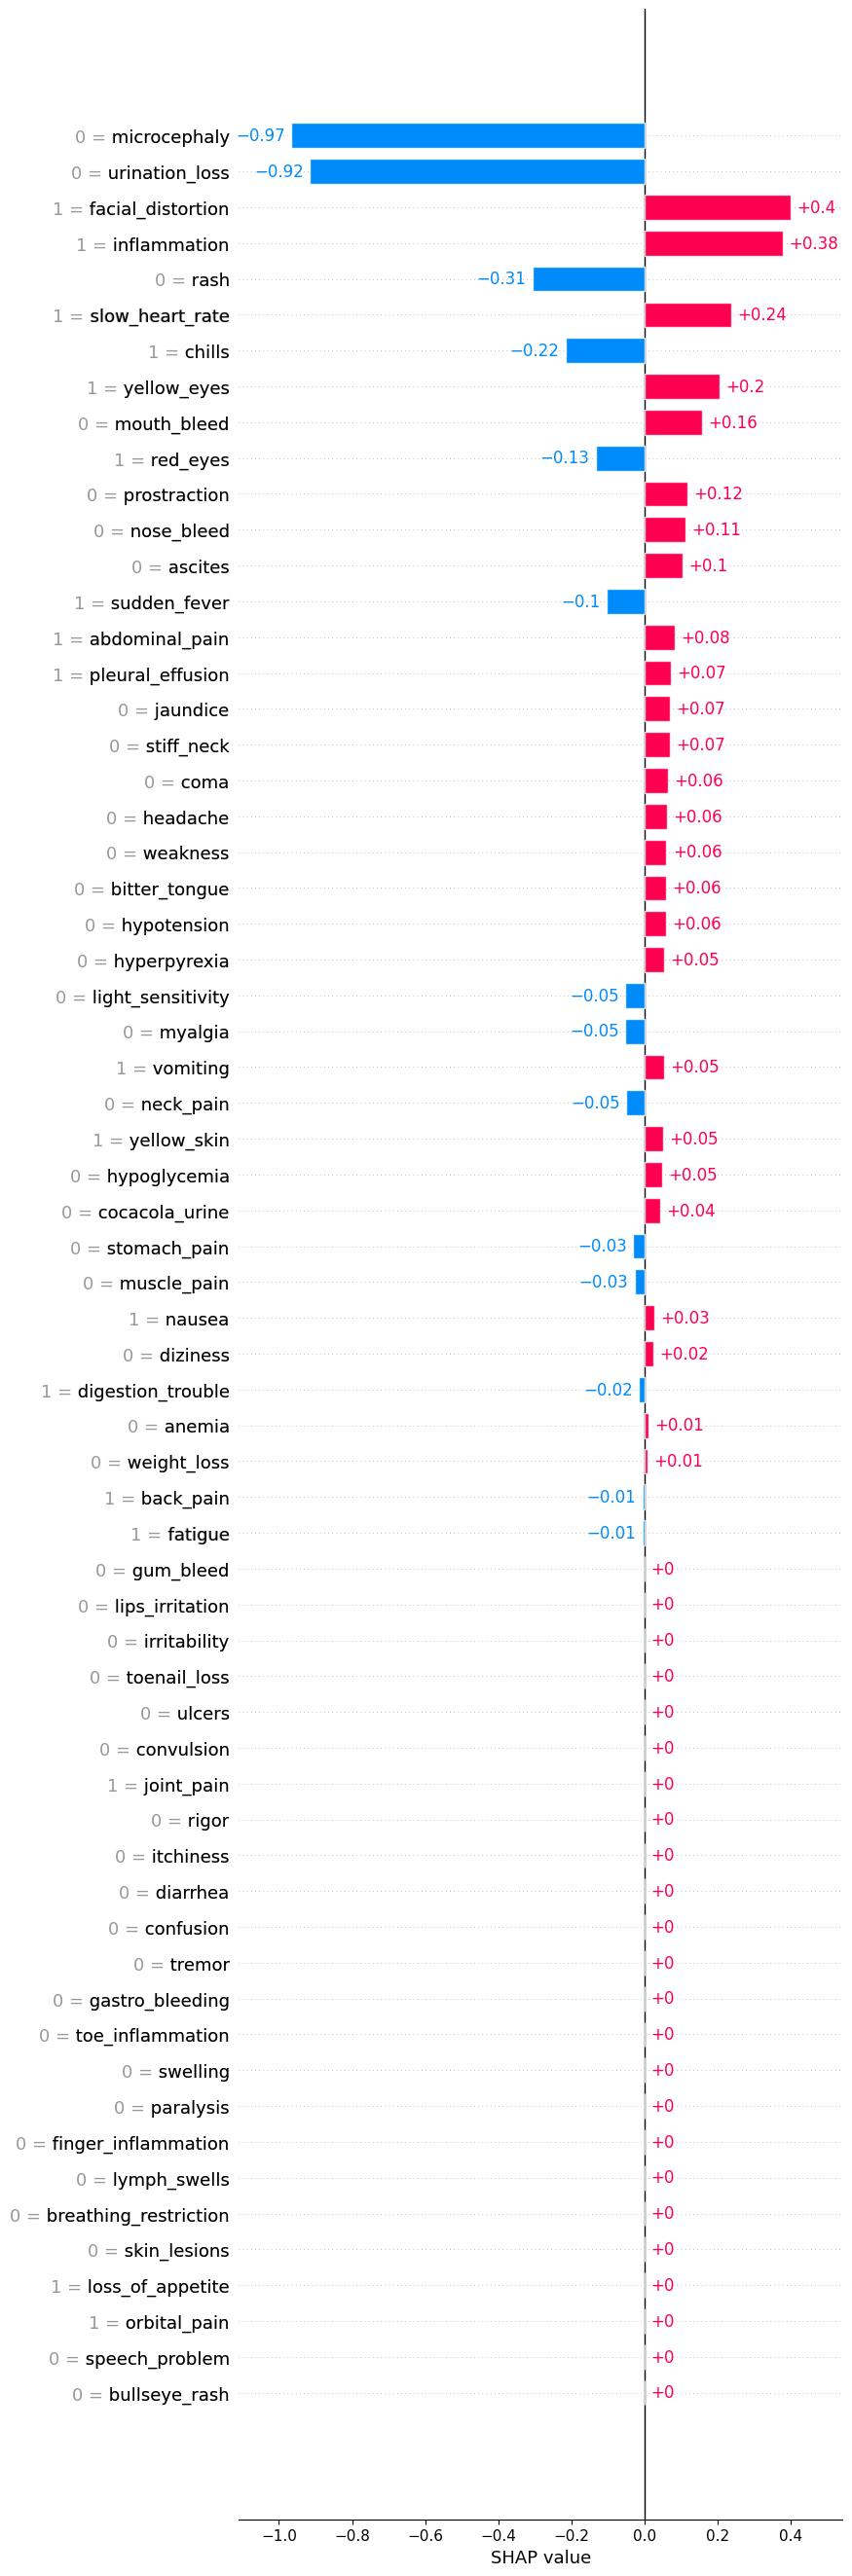


Bar plot:: Yellow Fever


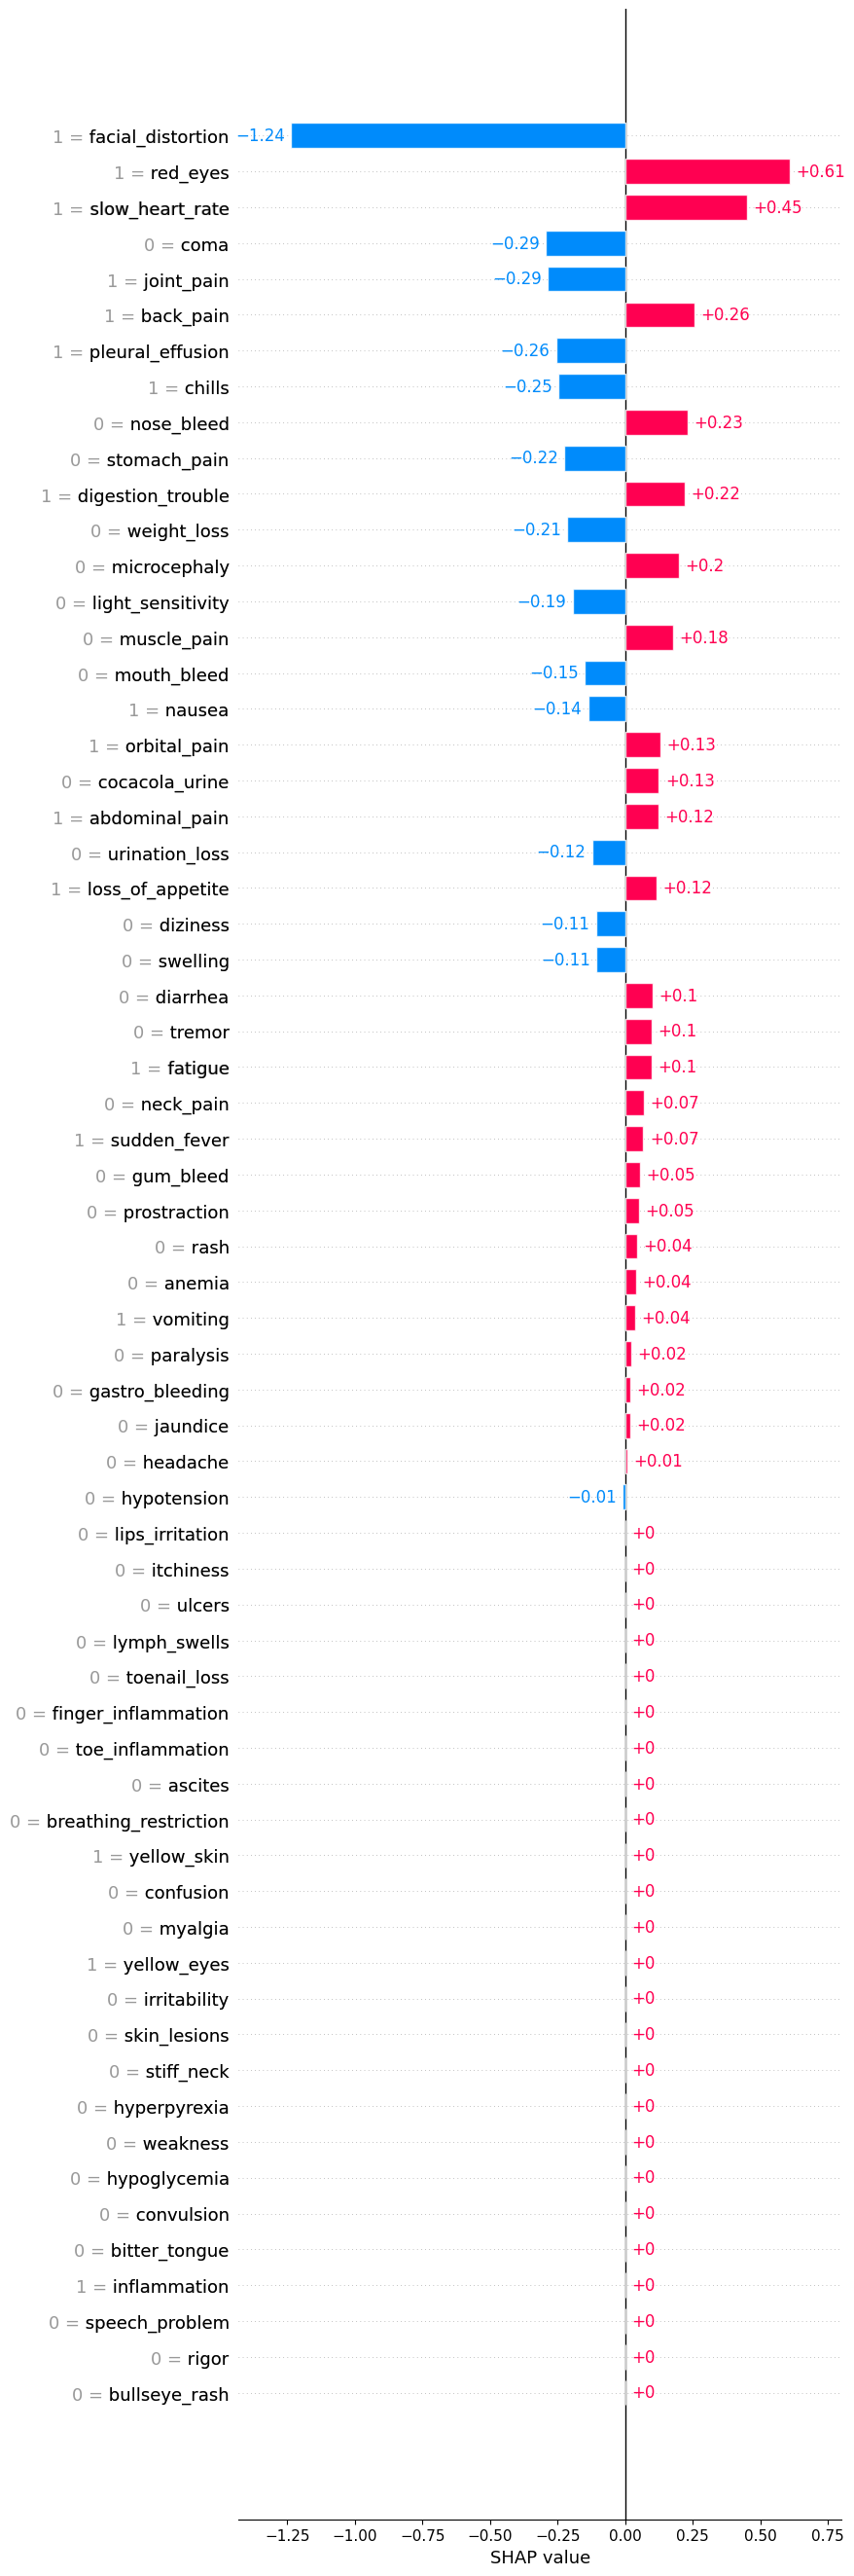

In [ ]:
# Print original and predicted class labels by the model for sample at index 12
y_pred = xg_boost.predict(X_test)
original_class = label_encoder.inverse_transform([y_test.iloc[12]])[0]
predicted_class = label_encoder.inverse_transform([y_pred[12]])[0]

print(f"\nOriginal Class: {original_class}")
print(f"Predicted Class by Model: {predicted_class}")

#print(f"\nOriginal Class: {original_class}")
print(f"\nBar plot: {original_class}")
import shap
import xgboost as xgb
import pandas as pd

# Assuming shap_values is already computed for a multi-class classification model
shap_values = explainer.shap_values(X_test)

# Select SHAP values for sample at index 12, all features, and only for the class=10 (index 10)
shap_values_sample12_class10 = shap_values[12, :, 10]

# Ensure X_test is a DataFrame to have column names
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Create an Explanation object for the specific sample (index 12) and class=10
explanation = shap.Explanation(values=shap_values_sample12_class10,
                               base_values=explainer.expected_value[10],
                               data=X_test.iloc[12],  # Select the specific sample (index 12)
                               feature_names=feature_names)

# Generate bar plot for the selected sample and class=10
shap.plots.bar(explanation,max_display=65, show=True)




#print(f"Predicted Class by Model: {predicted_class}")
print(f"\nBar plot:: {predicted_class}")

# Select SHAP values for sample at index 12, all features, and only for the class=9 (index 9)
shap_values_sample12_class9 = shap_values[12, :, 9]

# Create an Explanation object for the specific sample (index 12) and class=9
explanation_yellow_fever = shap.Explanation(values=shap_values_sample12_class9,
                                            base_values=explainer.expected_value[9],
                                            data=X_test.iloc[12],  # Select the specific sample (index 12)
                                            feature_names=feature_names)

# Generate bar plot for the selected sample and class=9 (Yellow Fever)
shap.plots.bar(explanation_yellow_fever,max_display=65, show=True)




<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=82fc1969-7ff0-4344-a3e7-65ed95a291e5' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>